# t-SNE — An Illustrated Tour

> **t-Distributed Stochastic Neighbour Embedding** preserves *local* structure: neighbours in high-D stay neighbours in 2-D. Excellent for **visualising clusters**, terrible for measuring distances or extrapolating.

---

**What we cover:**
- The objective: match neighbour-probability distributions $P$ (high-D) and $Q$ (low-D)
- The role of **perplexity** — effective number of neighbours
- Sweep perplexity on the digits dataset
- t-SNE vs PCA on the same data
- Things t-SNE will **not** tell you (cluster sizes, distances)

## The picture — preserve *local* neighbourhoods; global distances are not meaningful

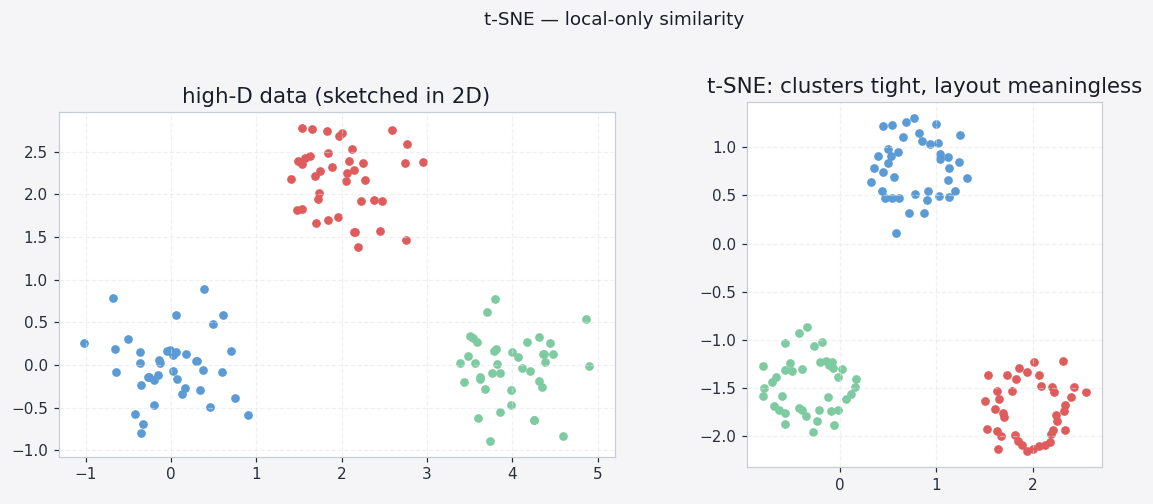

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
# High-D blobs (shown as 2D)
ax = axes[0]
for i, c in enumerate([P[0], P[1], P[3]]):
    pts = rng.randn(40, 2)*0.4 + np.array([i*2, (i%2)*2])
    ax.scatter(pts[:,0], pts[:,1], s=22, color=c)
ax.set_title('high-D data (sketched in 2D)'); ax.grid(True); ax.set_aspect('equal')
# t-SNE: clusters preserved, distances arbitrary
ax = axes[1]
for i, c in enumerate([P[0], P[1], P[3]]):
    th = np.linspace(0, 2*np.pi, 40) + rng.rand()
    r = 0.4 + 0.1*rng.randn(40)
    cx, cy = rng.uniform(-2, 2, 2)
    ax.scatter(cx + r*np.cos(th), cy + r*np.sin(th), s=22, color=c)
ax.set_title('t-SNE: clusters tight, layout meaningless')
ax.grid(True); ax.set_aspect('equal')
fig.suptitle('t-SNE — local-only similarity', y=1.03); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)

digits = load_digits()
X, y = digits.data, digits.target
print('Digits:', X.shape)

Digits: (1797, 64)


---
## Objective — Match Two Neighbour Distributions

**High-D similarities** (Gaussian, symmetrised):

$$p_{j\mid i} = \frac{\exp\!\bigl(-\|x_i - x_j\|^2 / 2\sigma_i^2\bigr)}{\sum_{k \neq i}\exp\!\bigl(-\|x_i - x_k\|^2 / 2\sigma_i^2\bigr)}, \qquad p_{ij} = \tfrac{1}{2N}\bigl(p_{j\mid i} + p_{i\mid j}\bigr).$$

Each $\sigma_i$ is chosen so that the entropy of $p_{\cdot\mid i}$ matches a target — the **perplexity**.

**Low-D similarities** use a heavy-tailed Student-$t$:

$$q_{ij} = \frac{\bigl(1 + \|y_i - y_j\|^2\bigr)^{-1}}{\sum_{k \neq l}\bigl(1 + \|y_k - y_l\|^2\bigr)^{-1}}.$$

Minimise $\operatorname{KL}(P \,\Vert\, Q) = \sum_{i\neq j} p_{ij}\log\frac{p_{ij}}{q_{ij}}$ by gradient descent on the embedding $Y$. The heavy tail of $t$ pushes far points further apart, **resolving clumps** instead of crushing them together.

---
## Perplexity Sweep

Perplexity controls the **effective number of neighbours** each point pays attention to.
Small perplexity → very local, fragmented; large perplexity → more global, blob-like.

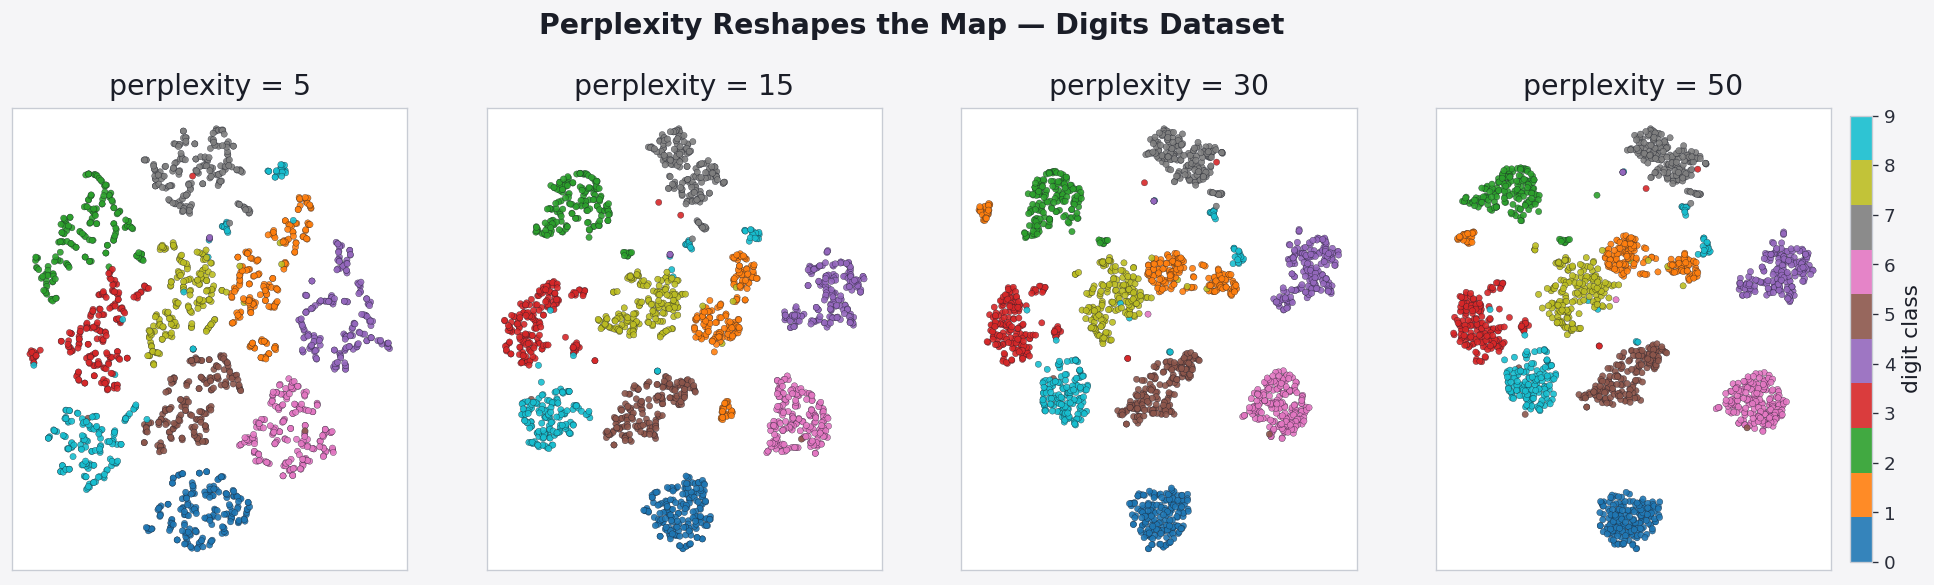

In [3]:
perps = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
cmap = plt.get_cmap('tab10')
for ax, p in zip(axes, perps):
    Z = TSNE(n_components=2, perplexity=p, init='pca',
             learning_rate='auto', random_state=0, max_iter=750).fit_transform(X)
    sc = ax.scatter(Z[:,0], Z[:,1], c=y, cmap=cmap, s=14, edgecolors='#1a1d27', lw=0.2, alpha=0.9)
    ax.set_title(f'perplexity = {p}', pad=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Perplexity Reshapes the Map — Digits Dataset', fontsize=17, fontweight='bold', y=1.04)
fig.colorbar(sc, ax=axes, fraction=0.012, pad=0.01, label='digit class')
plt.show()

---
## t-SNE vs PCA on the Same Data

PCA is a **linear** projection: it can only spread the data along directions of high variance. t-SNE bends and tears the manifold to keep neighbours close, exposing class clusters that PCA leaves overlapping.

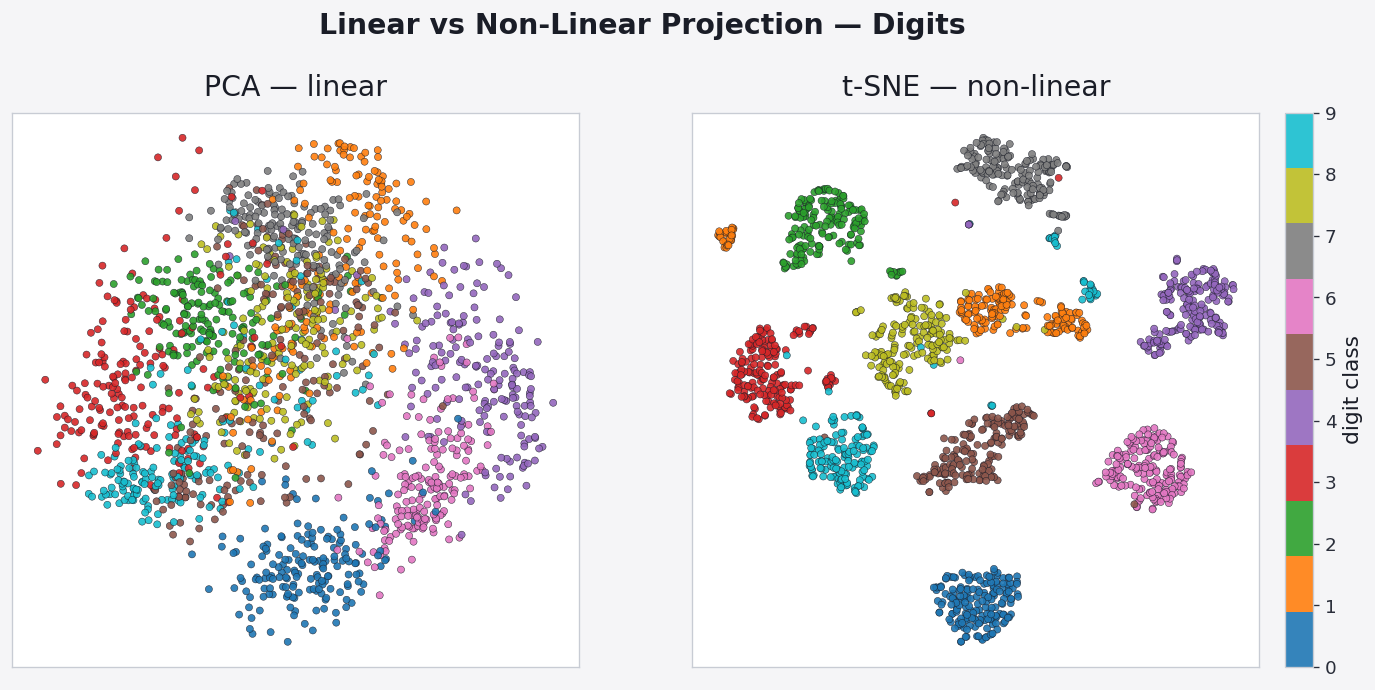

In [4]:
Z_pca = PCA(n_components=2).fit_transform(X)
Z_tsne = TSNE(n_components=2, perplexity=30, init='pca',
              learning_rate='auto', random_state=0, max_iter=750).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, Z, title in zip(axes, [Z_pca, Z_tsne], ['PCA — linear', 't-SNE — non-linear']):
    sc = ax.scatter(Z[:,0], Z[:,1], c=y, cmap=cmap, s=18, edgecolors='#1a1d27', lw=0.3, alpha=0.9)
    ax.set_title(title, pad=10); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Linear vs Non-Linear Projection — Digits', fontsize=17, fontweight='bold', y=1.02)
fig.colorbar(sc, ax=axes, fraction=0.022, pad=0.02, label='digit class')
plt.show()

---
## What t-SNE Does **Not** Preserve

- **Cluster sizes are meaningless.** A tight clump in the map can be a huge blob in original space, and vice versa.
- **Inter-cluster distances are unreliable.** Two clusters drawn far apart may not be especially distant in original space.
- **Random initialisation matters.** Two t-SNE runs can produce visually different maps; use `init='pca'` for stability.
- **No `transform` for new points.** t-SNE is a *visualisation*, not a re-usable embedding.

---
## ⚖️ When to use t-SNE — and when not to

| Situation | t-SNE | UMAP | PCA |
|---|---|---|---|
| Visualising clusters in 2-D | ✅ | ✅ similar quality | ❌ linear |
| Preserve global distances | ❌ | partial | ✅ |
| Embed new points (transform) | ❌ refits | ✅ has `transform` | ✅ |
| Big data ($n > 50\,000$) | ❌ $O(n^2)$ | ✅ | ✅ |

> t-SNE is for **visualisation only**, never as a feature extractor for downstream models.


---
## 🎯 Try this

1. **Run twice.** Fix the seed but change perplexity from 30 to 50 — clusters move, gaps change. The "shape" is not stable.
2. **Cluster-size lie.** Make one input cluster 10× bigger than another. In the t-SNE plot they look the same size — a hands-on demonstration of one of t-SNE's biggest myths.
3. **PCA pre-processing.** Reduce to 50-D with PCA before running t-SNE. Quality is similar; runtime drops dramatically. This is the standard recipe.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Goal | Match $P$ (high-D) and $Q$ (low-D) neighbour probabilities | Local structure preservation |
| Perplexity | Effective neighbours (5–50 typical) | Trade local vs global focus |
| Heavy tail | Student-$t$ in low-D | Avoids the *crowding problem* |
| Loss | $\mathrm{KL}(P\Vert Q)$, gradient descent | Non-convex — random init matters |
| Strength | Vivid cluster maps in 2-D / 3-D | Best general-purpose visualiser |
| Weakness | Slow $O(N^2)$ (use Barnes-Hut for big data); no `transform`; sizes/distances unreliable | Pair with PCA pre-reduction for speed |

**Bottom line:** Use t-SNE to **see** clusters; do not measure them with a ruler. Sweep perplexity, fix the seed, and pre-reduce with PCA for big data.